In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv('sales_data.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 14)


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.dtypes

Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object

In [7]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [8]:
numeric_cols = ['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']

corr_matrix = df[numeric_cols].corr()
corr_matrix

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
Sales_Amount,1.000000,-0.041599,0.009770,0.011812,0.023153
Quantity_Sold,-0.041599,1.000000,0.053888,0.057296,-0.007806
Unit_Cost,0.009770,0.053888,1.000000,0.995056,-0.017741
Unit_Price,0.011812,0.057296,0.995056,1.000000,-0.017027
Discount,0.023153,-0.007806,-0.017741,-0.017027,1.000000


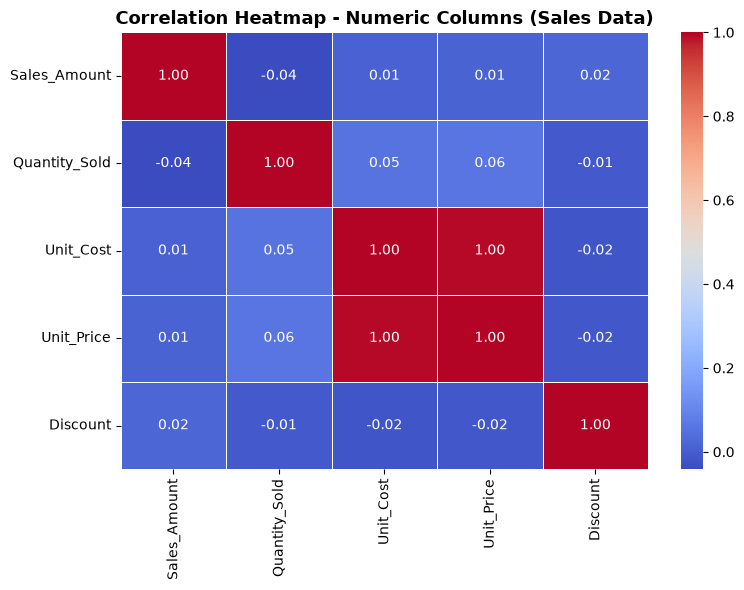

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Columns (Sales Data)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

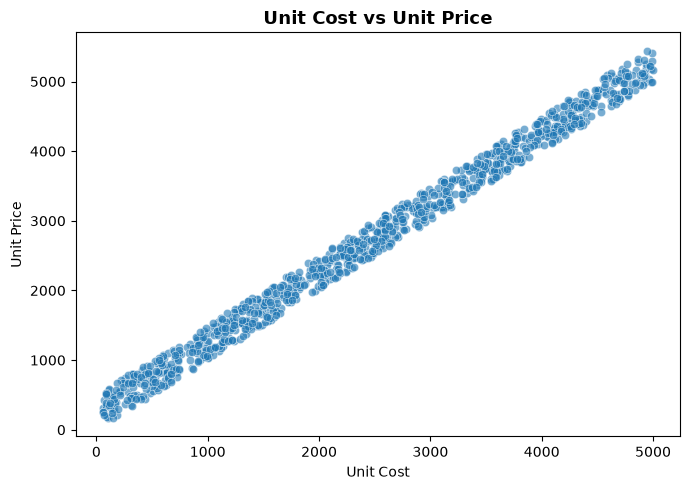

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Unit_Cost', y='Unit_Price', alpha=0.6)
plt.title('Unit Cost vs Unit Price', fontsize=13, weight='bold')
plt.xlabel('Unit Cost')
plt.ylabel('Unit Price')
plt.tight_layout()
plt.show()

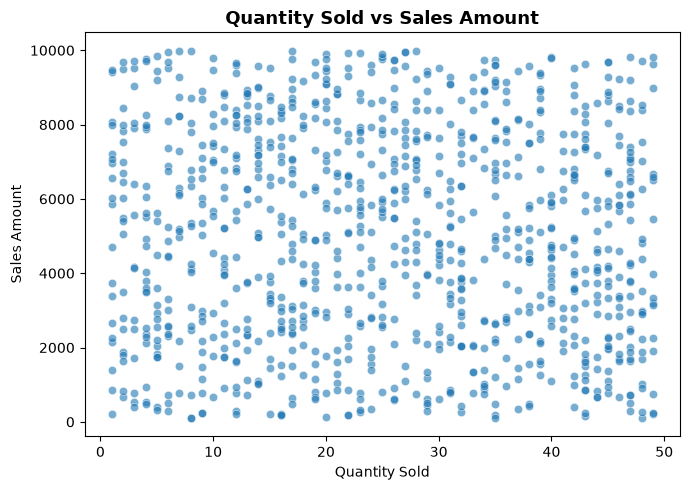

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Quantity_Sold', y='Sales_Amount', alpha=0.6)
plt.title('Quantity Sold vs Sales Amount', fontsize=13, weight='bold')
plt.xlabel('Quantity Sold')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

Product_Category
Food           5317.582035
Electronics    5054.876585
Clothing       4901.023731
Furniture      4848.144962
Name: Sales_Amount, dtype: float64


C:\Users\Intel Computer\AppData\Local\Temp\ipykernel_1740\301930692.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_avg.index, y=category_avg.values, palette='viridis')


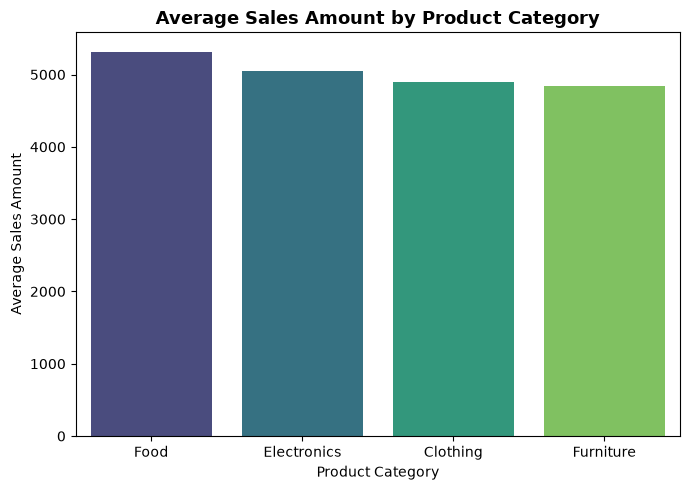

In [12]:
category_avg = df.groupby('Product_Category')['Sales_Amount'].mean().sort_values(ascending=False)
print(category_avg)

plt.figure(figsize=(7, 5))
sns.barplot(x=category_avg.index, y=category_avg.values, palette='viridis')
plt.title('Average Sales Amount by Product Category', fontsize=13, weight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Sales Amount')
plt.tight_layout()
plt.show()

Region
North    5129.634869
South    5107.304690
West     5063.971025
East     4790.087186
Name: Sales_Amount, dtype: float64


C:\Users\Intel Computer\AppData\Local\Temp\ipykernel_1740\215449882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index, y=region_avg.values, palette='mako')


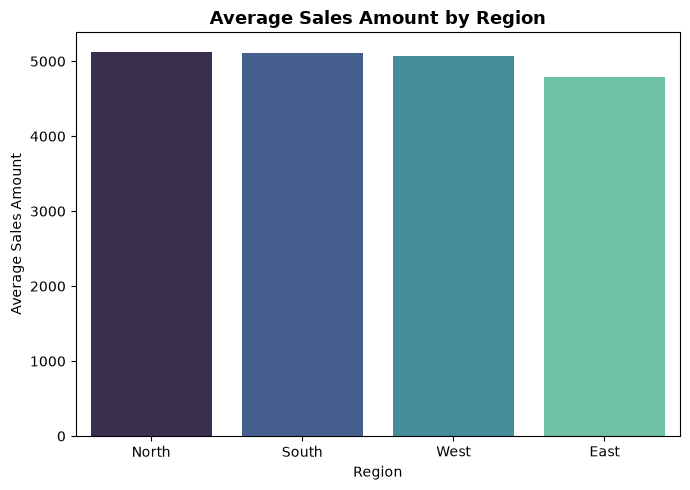

In [14]:
region_avg = df.groupby('Region')['Sales_Amount'].mean().sort_values(ascending=False)
print(region_avg)

plt.figure(figsize=(7, 5))
sns.barplot(x=region_avg.index, y=region_avg.values, palette='mako')
plt.title('Average Sales Amount by Region', fontsize=13, weight='bold')
plt.xlabel('Region')
plt.ylabel('Average Sales Amount')
plt.tight_layout()
plt.show()